In [1]:
import pandas as pd
import numpy as np

In [2]:
results_1 = "./analysis_results/2022_barn_2secs_myca_quantile_1_16"
results_2 = "./analysis_results/2022_lake_2secs_myca_quantile_1_28"

In [3]:
chirp_attributes_1 = pd.read_csv(f"{results_1}/test_set_chirp_attributes.csv")
idiom_boundaries_1 = pd.read_csv(f"{results_1}/idiom_boundaries.csv")
confidence_measures_1 = pd.read_csv(f"{results_1}/chirp_prediction_confidence_measures.csv")

chirp_attributes_2 = pd.read_csv(f"{results_2}/test_set_chirp_attributes.csv")
idiom_boundaries_2 = pd.read_csv(f"{results_2}/idiom_boundaries.csv")
confidence_measures_2 = pd.read_csv(f"{results_2}/chirp_prediction_confidence_measures.csv")

In [4]:
combined_chirp_attributes = pd.concat([chirp_attributes_1, chirp_attributes_2], ignore_index=True)
combined_chirp_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
idiom_boundaries_attributes = pd.concat([idiom_boundaries_1, idiom_boundaries_2], ignore_index=True)
idiom_boundaries_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
confidence_measures_attributes = pd.concat([confidence_measures_1, confidence_measures_2], ignore_index=True)
confidence_measures_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,...,8769.741215,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0
1,1,1848.999988,82.0,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,...,14213.696222,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0
2,2,1680.000025,83.0,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,...,4357.833382,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0
3,3,1596.999944,90.0,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,...,18380.062892,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0
4,4,1506.999984,79.0,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,...,19015.930484,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11448,553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090.0,10.0
11449,554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090.0,9.0
11450,555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090.0,8.0
11451,556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090.0,7.0


In [5]:
for dataframe, df_1 in [(combined_chirp_attributes, chirp_attributes_1), 
                        (idiom_boundaries_attributes, idiom_boundaries_1), 
                        (confidence_measures_attributes, confidence_measures_1)]:
    dataframe["original_df"] = dataframe.apply(lambda x: 1 if x.name < len(df_1) else 2, axis=1)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,...,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0,1
1,1,1848.999988,82.0,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,...,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0,1
2,2,1680.000025,83.0,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
3,3,1596.999944,90.0,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
4,4,1506.999984,79.0,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11448,553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,...,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090.0,10.0,2
11449,554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,...,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090.0,9.0,2
11450,555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,...,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090.0,8.0,2
11451,556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,...,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090.0,7.0,2


In [6]:
import umap
combined_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(combined_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy())

/home/ayc227/miniconda3/envs/bats/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0, 0.5, 'UMAP Component 2')

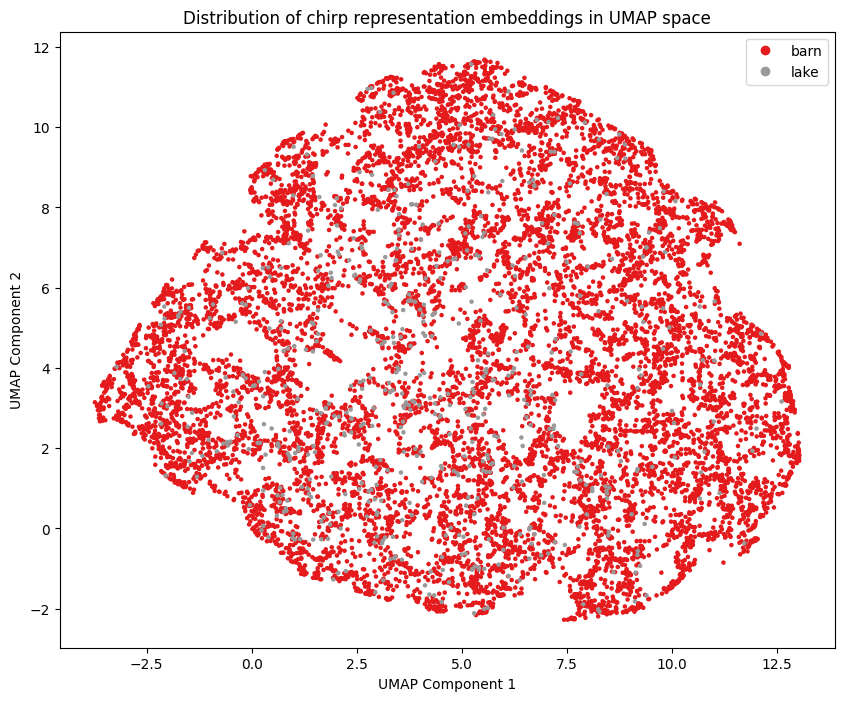

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_chirp_attributes_embedded[:, 0], combined_chirp_attributes_embedded[:, 1], c=combined_chirp_attributes["original_df"], cmap="Set1", s=5, 
                    #   vmin=min(chirp_labels), vmax=max(chirp_labels)
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, ["barn", "lake"])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);